In [1]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sksurv.ensemble import RandomSurvivalForest
from sksurv.meta import EnsembleSelection
from sksurv.svm import FastSurvivalSVM
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sksurv.metrics import (
    as_concordance_index_ipcw_scorer,
    as_cumulative_dynamic_auc_scorer,
    as_integrated_brier_score_scorer,
    concordance_index_ipcw
)

In [2]:
metadata= pd.read_csv('data/combined_metadata.csv')
y = Surv.from_arrays(event=metadata['metastasis_status'], time=metadata['time'])
X = pd.read_csv('data/lifeline_univ_cox_sig_expression.csv', index_col=0).convert_dtypes()

In [3]:
def remove_zero_time(y, X=None):
    """
    Remove samples with time == 0 from sksurv-formatted survival data.
    
    Parameters
    ----------
    y : structured array
        Survival array with fields ('event', 'time').
    X : array-like, optional
        Feature matrix corresponding to y.

    Returns
    -------
    y_filtered : structured array
    X_filtered : array-like (if X provided)
    """
    mask = y["time"] > 0
    y_filtered = y[mask]
    if X is not None:
        return y_filtered, X[mask]
    return y_filtered
y , X = remove_zero_time(y, X)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [68]:

def c_index_scorer(estimator, X, y):
    """
    Custom scorer for concordance index (C-index).
    
    Parameters:
    -----------
    estimator : sklearn estimator
        Fitted model
    X : array-like
        Features
    y : array-like
        Target values (risk scores or times)
    
    Returns:
    --------
    float : C-index score
    """
    #predictions = estimator.predict(X)
    #y_lifeline = convert_to_survival_format(y, return_df=True)

    return float(estimator.score(X,y))
    #concordance_index(y_lifeline['duration'], predictions, y_lifeline['event'])

for Enet papet mentions N1 hyperparam. I cant figure out what that it. the MIME paper uses alpha instead

Also they include testing data in the gridsearch, which seems wrong

In [69]:


# Define a generic pipeline with an 'estimator' placeholder
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('estimator', RandomSurvivalForest(random_state=42)) # Default estimator
])
#define base models
rsf = RandomSurvivalForest(random_state=42)
svm = FastSurvivalSVM(random_state=42)
lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
enet = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01)
boost_cox = GradientBoostingSurvivalAnalysis(learning_rate=1.0, max_depth=1, random_state=0)

ensemble = EnsembleSelection([('rsf', rsf), ('svm',svm)], scorer=c_index_scorer)


# Parameter grid for Random Survival Forest
param_grid_rsf = {
    'estimator': [rsf]#,
    #'estimator__n_estimators': [100],
    #'estimator__max_depth': [10]
}

# Parameter grid for Fast Survival SVM
param_grid_svm = {
    'estimator': [svm]
    #'estimator__alpha': [2.0**v for v in range(-12, -8, 2)]
}

# Parameter grid for Fast Lasso
param_grid_lasso = {
    'estimator': [lasso],
    'estimator__alpha_min_ratio': [0.01, 0.1]
}
# Parameter grid for E net
param_grid_Enet = {
    'estimator': [enet],
    'estimator__alpha_min_ratio': [0.01, 0.1]
}

params_boost_cox = {
    'estimator': [boost_cox]
}

import itertools
names_list = ['rsf', 'svm', 'lasso', 'enet',  'boost_cox']
model_list = [rsf, svm, lasso,enet,  boost_cox ]

# get all permutations of two
name_model =tuple(zip(names_list, model_list))
combos =[[a,b] for a, b in itertools.combinations(name_model,2)]


param_grid_ensamble = {
    'estimator': [ensemble],
    'estimator__base_estimators': combos
}

# Combine all parameter grids into a single list
full_param_grid = [param_grid_rsf,
                    param_grid_svm,
                    param_grid_lasso,
                    param_grid_Enet,
                    params_boost_cox,
                    param_grid_ensamble]


In [7]:
# Assuming appropriate X and y data (y should be a structured array)
# X, y = load_veterans_lung_cancer() 

# Initialize GridSearchCV
grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=full_param_grid,
            cv=3,
            scoring=c_index_scorer,
            n_jobs=8,
            verbose=3
        )

# Fit the grid search to your training data (X_train, y_train)
grid_search.fit(X_train, y_train) 


Fitting 3 folds for each of 17 candidates, totalling 51 fits


/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sklearn/pipeline.py:663: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  self._final_estimator.fit(Xt, y, **last_step_params["fit"])


[CV 1/3] END estimator=FastSurvivalSVM(random_state=42);, score=0.806 total time=   1.5s


/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sklearn/pipeline.py:663: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  self._final_estimator.fit(Xt, y, **last_step_params["fit"])
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sklearn/pipeline.py:663: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  self._final_estimator.fit(Xt, y, **last_step_params["fit"])


[CV 2/3] END estimator=FastSurvivalSVM(random_state=42);, score=0.806 total time=   1.6s
[CV 3/3] END estimator=FastSurvivalSVM(random_state=42);, score=0.819 total time=   1.6s
[CV 1/3] END estimator=CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0), estimator__alpha_min_ratio=0.01;, score=0.735 total time=   1.7s
[CV 1/3] END estimator=RandomSurvivalForest(random_state=42);, score=0.755 total time=   3.0s
[CV 2/3] END estimator=RandomSurvivalForest(random_state=42);, score=0.806 total time=   3.1s
[CV 2/3] END estimator=CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0), estimator__alpha_min_ratio=0.01;, score=0.806 total time=   1.8s
[CV 3/3] END estimator=RandomSurvivalForest(random_state=42);, score=0.767 total time=   3.2s
[CV 3/3] END estimator=CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0), estimator__alpha_min_ratio=0.01;, score=0.808 total time=   1.7s
[CV 1/3] END estimator=CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0), estimator__al

/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_trai

[CV 1/3] END estimator=GradientBoostingSurvivalAnalysis(learning_rate=1.0, max_depth=1, random_state=0);, score=0.759 total time=   8.0s
[CV 2/3] END estimator=GradientBoostingSurvivalAnalysis(learning_rate=1.0, max_depth=1, random_state=0);, score=0.697 total time=   7.9s
[CV 1/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x14f8eb1341f0>), estimator__base_estimators=[('rsf', RandomSurvivalForest(random_state=42)), ('svm', FastSurvivalSVM(random_state=42))];, score=0.776 total time=   7.3s


/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)


[CV 2/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x14eeaffcc1f0>), estimator__base_estimators=[('rsf', RandomSurvivalForest(random_state=42)), ('svm', FastSurvivalSVM(random_state=42))];, score=0.801 total time=   7.3s
[CV 3/3] END estimator=GradientBoostingSurvivalAnalysis(learning_rate=1.0, max_depth=1, random_state=0);, score=0.773 total time=   8.0s


/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)


[CV 1/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x14d60d3741f0>), estimator__base_estimators=[('rsf', RandomSurvivalForest(random_state=42)), ('lasso', CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0))];, score=0.776 total time=   7.8s
[CV 3/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x152e965d41f0>), estimator__base_estimators=[('rsf', RandomSurvivalForest(random_state=42)), ('svm', FastSurvivalSVM(random_state=42))];, score=0.826 total time=   8.2s
[CV 2/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                  

/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_trai

[CV 1/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x1528da6881f0>), estimator__base_estimators=[('svm', FastSurvivalSVM(random_state=42)), ('lasso', CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0))];, score=0.803 total time=   3.6s


/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_trai

[CV 1/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x1508f41e81f0>), estimator__base_estimators=[('rsf', RandomSurvivalForest(random_state=42)), ('enet', CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=0.9))];, score=0.776 total time=   7.6s
[CV 2/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x14f8eb1341f0>), estimator__base_estimators=[('rsf', RandomSurvivalForest(random_state=42)), ('enet', CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=0.9))];, score=0.811 total time=   7.7s
[CV 3/3] END estimator=EnsembleSelection(base_estimators=[

/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_trai

[CV 3/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x1508f41e81f0>), estimator__base_estimators=[('svm', FastSurvivalSVM(random_state=42)), ('lasso', CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0))];, score=0.826 total time=   3.7s
[CV 1/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x14f8eb1341f0>), estimator__base_estimators=[('svm', FastSurvivalSVM(random_state=42)), ('enet', CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=0.9))];, score=0.803 total time=   3.4s
[CV 2/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
 

/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_train, y_train, **train_params)
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  est.fit(X_trai

[CV 1/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x1541d4e901f0>), estimator__base_estimators=[('lasso', CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0)), ('enet', CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=0.9))];, score=0.755 total time=   3.8s
[CV 2/3] END estimator=EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x14eeaffcc1f0>), estimator__base_estimators=[('lasso', CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0)), ('enet', CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=0.9))];, score=0.798 total time=   3.8s
[CV 3/3] END

/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sklearn/pipeline.py:663: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  self._final_estimator.fit(Xt, y, **last_step_params["fit"])


,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'estimator': [RandomSurviva...ndom_state=42)]}, {'estimator': [FastSurvivalS...ndom_state=42)]}, ...]"
,scoring,<function c_i...x14da377fcb80>
,n_jobs,8
,refit,True
,cv,3
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [8]:
# The best_params_ and best_score_ attributes are not available when refit=False
# You need to manually find the best results from cv_results_
results = grid_search.cv_results_
# Find the index of the best score
best_index = np.argmax(results['mean_test_score'])
best_score = results['mean_test_score'][best_index]
best_params = results['params'][best_index]

print(f"Best score (C-index): {best_score}")
print(f"Best parameters: {best_params}")


Best score (C-index): 0.8102835929336597
Best parameters: {'estimator': FastSurvivalSVM(random_state=42)}


In [9]:
results_df = pd.DataFrame(results)
results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator,param_estimator__alpha_min_ratio,param_estimator__base_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,2.840684,0.083394,0.278744,0.000582,RandomSurvivalForest(random_state=42),NaN,NaN,{'estimator': RandomSurvivalForest(random_stat...,0.755102,0.805901,0.767318,0.776107,0.021650,12
1,1.279896,0.028519,0.274698,0.000143,FastSurvivalSVM(random_state=42),NaN,NaN,{'estimator': FastSurvivalSVM(random_state=42)},0.806122,0.805901,0.818828,0.810284,0.006042,1
2,1.415116,0.048990,0.304223,0.022217,"CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l...",0.01,NaN,{'estimator': CoxnetSurvivalAnalysis(alpha_min...,0.734694,0.805901,0.808171,0.782922,0.034115,11
3,1.182838,0.110521,0.278546,0.006936,"CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l...",0.10,NaN,{'estimator': CoxnetSurvivalAnalysis(alpha_min...,0.715986,0.760870,0.820604,0.765820,0.042853,16
4,1.404775,0.055632,0.297231,0.016436,"CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l...",0.01,NaN,{'estimator': CoxnetSurvivalAnalysis(alpha_min...,0.756803,0.813665,0.804618,0.791695,0.024948,6
5,1.127680,0.026307,0.276350,0.001651,"CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l...",0.10,NaN,{'estimator': CoxnetSurvivalAnalysis(alpha_min...,0.736395,0.773292,0.817052,0.775579,0.032968,13
6,7.680221,0.042909,0.297466,0.014358,GradientBoostingSurvivalAnalysis(learning_rate...,NaN,NaN,{'estimator': GradientBoostingSurvivalAnalysis...,0.759354,0.697205,0.772647,0.743068,0.032881,17
7,7.313733,0.390339,0.299561,0.004410,"EnsembleSelection(base_estimators=[('rsf',\n ...",NaN,"[(rsf, RandomSurvivalForest(random_state=42)),...",{'estimator': EnsembleSelection(base_estimator...,0.775510,0.801242,0.825933,0.800895,0.020586,5
8,7.532116,0.269726,0.472947,0.024621,"EnsembleSelection(base_estimators=[('rsf',\n ...",NaN,"[(rsf, RandomSurvivalForest(random_state=42)),...",{'estimator': EnsembleSelection(base_estimator...,0.775510,0.810559,0.788632,0.791567,0.014458,7
9,7.316702,0.161530,0.413472,0.020448,"EnsembleSelection(base_estimators=[('rsf',\n ...",NaN,"[(rsf, RandomSurvivalForest(random_state=42)),...",{'estimator': EnsembleSelection(base_estimator...,0.775510,0.810559,0.788632,0.791567,0.014458,7


In [10]:
import re
#build name for chart 

#add model name
results_df['model_name']=results_df['param_estimator'].astype('str').str.extract(r"^(.*?)\(", expand=False)

#add alpha if there


In [11]:

def add_alpha(x):
    if np.isnan(x):
        return ""
    else:
        return f"-\u03B1:{x}"

add = results_df['param_estimator__alpha_min_ratio'].apply(add_alpha)
results_df['model_name'] =results_df['model_name']+pd.Series(add)

In [12]:
#now for ensamble


def add_base_estimators(x):
    if x!=x:
        return ""
    else:
        a= x[0][0]
        b= x[1][0]
        return f'-{a}+{b}'
add = results_df['param_estimator__base_estimators'].apply(add_base_estimators)
results_df['model_name'] += add

In [13]:
results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator,param_estimator__alpha_min_ratio,param_estimator__base_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,model_name
0,2.840684,0.083394,0.278744,0.000582,RandomSurvivalForest(random_state=42),NaN,NaN,{'estimator': RandomSurvivalForest(random_stat...,0.755102,0.805901,0.767318,0.776107,0.021650,12,RandomSurvivalForest
1,1.279896,0.028519,0.274698,0.000143,FastSurvivalSVM(random_state=42),NaN,NaN,{'estimator': FastSurvivalSVM(random_state=42)},0.806122,0.805901,0.818828,0.810284,0.006042,1,FastSurvivalSVM
2,1.415116,0.048990,0.304223,0.022217,"CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l...",0.01,NaN,{'estimator': CoxnetSurvivalAnalysis(alpha_min...,0.734694,0.805901,0.808171,0.782922,0.034115,11,CoxnetSurvivalAnalysis-α:0.01
3,1.182838,0.110521,0.278546,0.006936,"CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l...",0.10,NaN,{'estimator': CoxnetSurvivalAnalysis(alpha_min...,0.715986,0.760870,0.820604,0.765820,0.042853,16,CoxnetSurvivalAnalysis-α:0.1
4,1.404775,0.055632,0.297231,0.016436,"CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l...",0.01,NaN,{'estimator': CoxnetSurvivalAnalysis(alpha_min...,0.756803,0.813665,0.804618,0.791695,0.024948,6,CoxnetSurvivalAnalysis-α:0.01
5,1.127680,0.026307,0.276350,0.001651,"CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l...",0.10,NaN,{'estimator': CoxnetSurvivalAnalysis(alpha_min...,0.736395,0.773292,0.817052,0.775579,0.032968,13,CoxnetSurvivalAnalysis-α:0.1
6,7.680221,0.042909,0.297466,0.014358,GradientBoostingSurvivalAnalysis(learning_rate...,NaN,NaN,{'estimator': GradientBoostingSurvivalAnalysis...,0.759354,0.697205,0.772647,0.743068,0.032881,17,GradientBoostingSurvivalAnalysis
7,7.313733,0.390339,0.299561,0.004410,"EnsembleSelection(base_estimators=[('rsf',\n ...",NaN,"[(rsf, RandomSurvivalForest(random_state=42)),...",{'estimator': EnsembleSelection(base_estimator...,0.775510,0.801242,0.825933,0.800895,0.020586,5,EnsembleSelection-rsf+svm
8,7.532116,0.269726,0.472947,0.024621,"EnsembleSelection(base_estimators=[('rsf',\n ...",NaN,"[(rsf, RandomSurvivalForest(random_state=42)),...",{'estimator': EnsembleSelection(base_estimator...,0.775510,0.810559,0.788632,0.791567,0.014458,7,EnsembleSelection-rsf+lasso
9,7.316702,0.161530,0.413472,0.020448,"EnsembleSelection(base_estimators=[('rsf',\n ...",NaN,"[(rsf, RandomSurvivalForest(random_state=42)),...",{'estimator': EnsembleSelection(base_estimator...,0.775510,0.810559,0.788632,0.791567,0.014458,7,EnsembleSelection-rsf+enet


<Axes: >

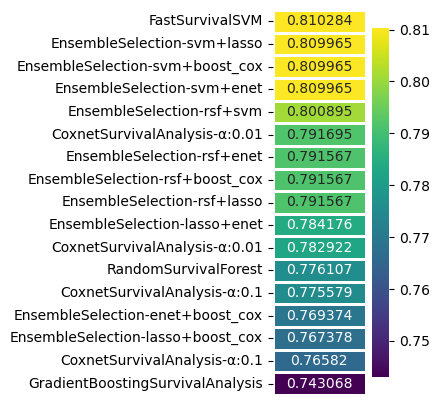

In [14]:
df_sorted = results_df.sort_values("mean_test_score", ascending=False)

heat_data = df_sorted["mean_test_score"].to_frame()
plt.figure(figsize=(1.5, 5))
sns.heatmap(
    heat_data,
    cmap="viridis",
    cbar=True,
    annot=True,         # ← add values inside cells
    fmt="g",
    linewidths=1,
    yticklabels=df_sorted["model_name"],
    xticklabels=[]
)

In [15]:

cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
cox_lasso.fit(X_test, y_test)

c_index_scorer(cox_lasso, X_train, y_train)

0.6312716657544244

In [16]:
def plot_coefficients(coefs, n_highlight):
    _, ax = plt.subplots(figsize=(9, 6))
    alphas = coefs.columns
    for row in coefs.itertuples():
        ax.semilogx(alphas, row[1:], ".-", label=row.Index)

    alpha_min = alphas.min()
    top_coefs = coefs.loc[:, alpha_min].map(abs).sort_values().tail(n_highlight)
    for name in top_coefs.index:
        coef = coefs.loc[name, alpha_min]
        plt.text(alpha_min, coef, name + "   ", horizontalalignment="right", verticalalignment="center")

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.grid(True)
    ax.set_xlabel("alpha")
    ax.set_ylabel("coefficient")

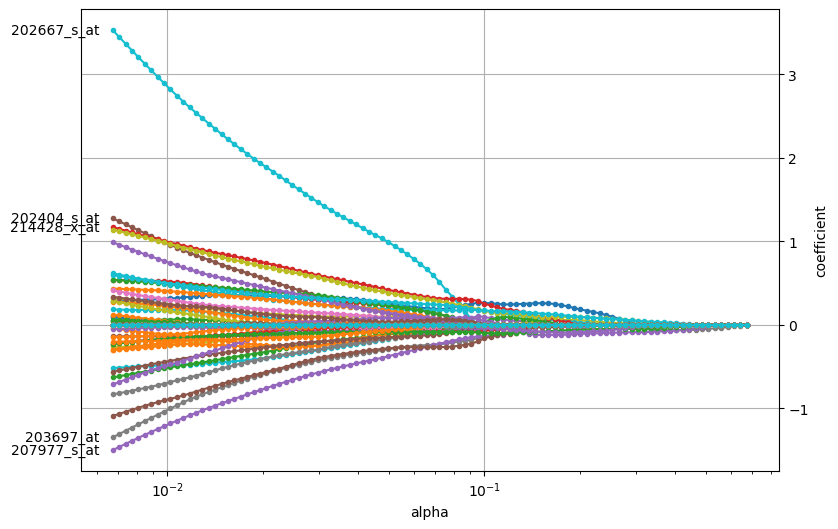

In [17]:
coefficients_lasso = pd.DataFrame(cox_lasso.coef_, index=X.columns, columns=np.round(cox_lasso.alphas_, 5))

plot_coefficients(coefficients_lasso, n_highlight=5)

In [18]:
coefficients_lasso.sort_values(0.00673, ascending=False)

,0.67308,0.64249,0.61329,0.58541,0.55880,0.53341,0.50916,0.48602,0.46393,0.44284,...,0.01023,0.00977,0.00932,0.00890,0.00849,0.00811,0.00774,0.00739,0.00705,0.00673
202667_s_at,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.817201,2.892562,2.969569,3.047450,3.125305,3.204378,3.283750,3.364448,3.446175,3.528312
202404_s_at,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.956077,0.990044,1.025264,1.060615,1.095622,1.130972,1.166201,1.201909,1.237971,1.273698
214428_x_at,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.984310,1.003734,1.023501,1.043704,1.063862,1.084477,1.105048,1.126089,1.147497,1.168851
216379_x_at,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.963746,0.984991,1.005760,1.025811,1.044922,1.063906,1.082454,1.101083,1.119772,1.138059
219140_s_at,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.737049,0.763254,0.789934,0.816990,0.844102,0.871877,0.899805,0.928498,0.957798,0.987141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214040_s_at,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.475730,-0.497791,-0.521712,-0.546839,-0.572967,-0.600159,-0.627995,-0.656687,-0.686016,-0.715403
211998_at,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.685774,-0.705937,-0.725119,-0.742615,-0.759049,-0.774853,-0.790327,-0.805450,-0.820283,-0.834746
213032_at,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.888202,-0.907204,-0.927710,-0.949321,-0.971423,-0.994589,-1.018195,-1.042766,-1.068154,-1.093532
203697_at,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.003426,-1.041050,-1.078814,-1.116799,-1.154608,-1.193011,-1.231354,-1.270398,-1.310024,-1.349481


# finding optimal alpha for E-net


In [5]:
import warnings
from sklearn.pipeline import make_pipeline
from sklearn.exceptions import FitFailedWarning

coxnet_pipe = make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100))
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FitFailedWarning)
coxnet_pipe.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('coxnetsurvivalanalysis', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_alphas,100
,alphas,None
,alpha_min_ratio,0.01
,l1_ratio,0.9


In [10]:
#normaly we would test all the alpha values.
#to save time and computation, I will check every third
estimated_alphas = coxnet_pipe.named_steps["coxnetsurvivalanalysis"].alphas_
print("original sampling", estimated_alphas.shape)
mini_alphas = estimated_alphas[::3]
print("testing size", mini_alphas.size)

original sampling (100,)
testing size 34


In [13]:

cv = KFold(n_splits=3, shuffle=True, random_state=0)
gcv = GridSearchCV(
    make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9)),
    param_grid={"coxnetsurvivalanalysis__alphas": [[v] for v in map(float, mini_alphas)]},
    cv=cv,
    error_score=0.5,
    n_jobs=8,
).fit(X_train, y_train)

cv_results = pd.DataFrame(gcv.cv_results_)

In [14]:
cv_results.to_csv('data/determening_alpha_for_Enet.csv')

In [15]:
import pickle

with open("data/gridsearch.pkl", "wb") as f:
    pickle.dump(gcv, f)

In [ ]:
cv_results = pd.read_csv('data/determening_alpha_for_Enet.csv', index_col=0)

best alpha 0.0648024209138061


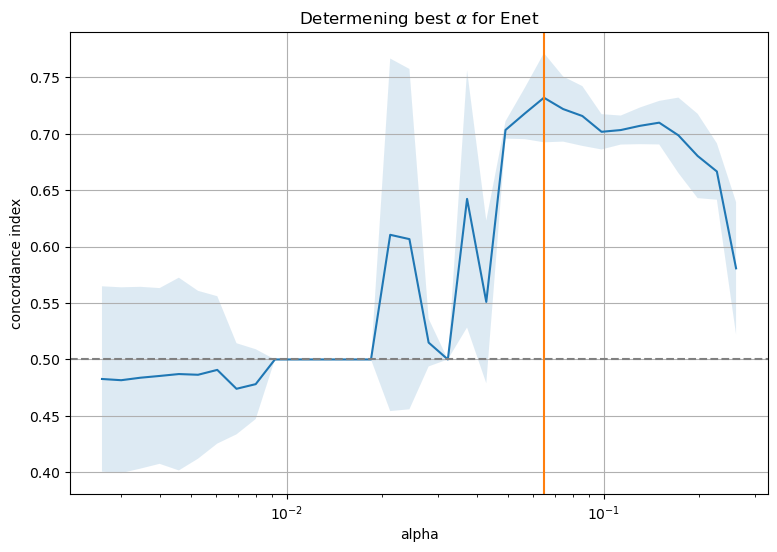

In [22]:
alphas = cv_results.param_coxnetsurvivalanalysis__alphas.map(lambda x: x[0])
mean = cv_results.mean_test_score
std = cv_results.std_test_score

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(alphas, mean)
ax.fill_between(alphas, mean - std, mean + std, alpha=0.15)
ax.set_xscale("log")
ax.set_ylabel("concordance index")
ax.set_xlabel("alpha")
ax.axvline(gcv.best_params_["coxnetsurvivalanalysis__alphas"][0], c="C1")
ax.axhline(0.5, color="grey", linestyle="--")
ax.grid(True)
best_alpha=gcv.best_params_["coxnetsurvivalanalysis__alphas"][0]
ax.set_title(f"Determening best $\\alpha$ for Enet ")
print("best alpha", best_alpha)

Number of non-zero coefficients: 59


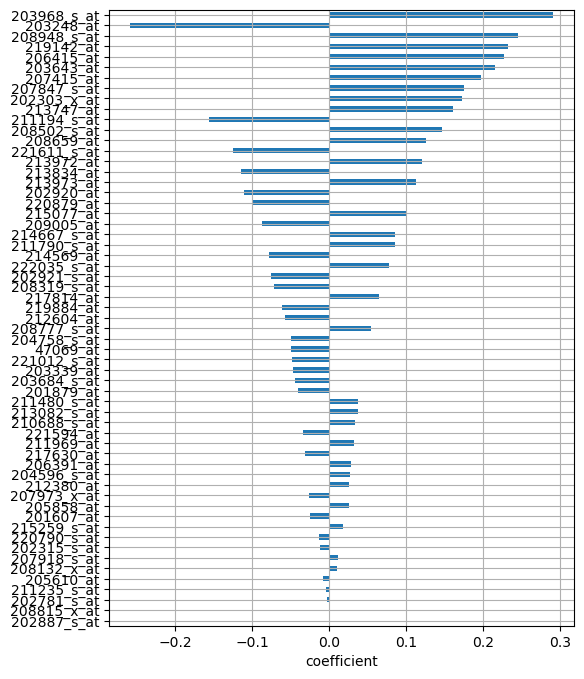

In [23]:
best_model = gcv.best_estimator_.named_steps["coxnetsurvivalanalysis"]
best_coefs = pd.DataFrame(best_model.coef_, index=X.columns, columns=["coefficient"])

non_zero = np.sum(best_coefs.iloc[:, 0] != 0)
print(f"Number of non-zero coefficients: {non_zero}")

non_zero_coefs = best_coefs.query("coefficient != 0")
coef_order = non_zero_coefs.abs().sort_values("coefficient").index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)
ax.set_xlabel("coefficient")
ax.grid(True)

Number of non-zero coefficients: 51


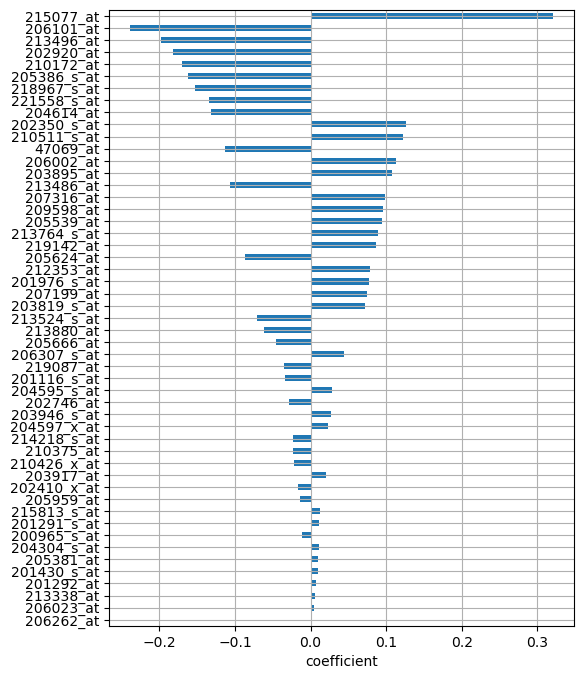

In [61]:
from sklearn.utils import shuffle
X_mix , y_mix = shuffle(X_train, y_train)
best_model.fit(X_mix,y_mix)
best_coefs = pd.DataFrame(best_model.coef_, index=X.columns, columns=["coefficient"])

non_zero = np.sum(best_coefs.iloc[:, 0] != 0)
print(f"Number of non-zero coefficients: {non_zero}")

non_zero_coefs = best_coefs.query("coefficient != 0")
coef_order = non_zero_coefs.abs().sort_values("coefficient").index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)
ax.set_xlabel("coefficient")
ax.grid(True)

In [31]:
len(non_zero_coefs.index.to_list())

51

In Mime defualts, they use LASSO 1000 times and keep anything that apears 50 times or more.
I will run Enet 100 times and keep anything 5 or more

In [45]:
from collections import Counter
#refit to shuffled data and count how many times things show up
total = Counter()
for i in range(100):
    #X_mix , y_mix = shuffle(X_train, y_train, random_state=i)
    X_mix, X_ignore, y_mix, y_ignore = train_test_split(X, y, test_size=0.3, random_state=i)
    best_model.fit(X_mix,y_mix)
    best_coefs = pd.DataFrame(best_model.coef_, index=X.columns, columns=["coefficient"])

    non_zero = np.sum(best_coefs.iloc[:, 0] != 0)

    non_zero_coefs = best_coefs.query("coefficient != 0")
    counts = Counter(non_zero_coefs.index.to_list())
    total = total + counts


In [46]:
series_total = pd.Series(total)

In [47]:
#finaly lets annotate with gene symbols
gene_info = pd.read_csv('data/gene_feature_scores_annotation.csv', index_col=0)
gene_info.head()

/scratch/1963571.1.academic/ipykernel_2186055/2223809677.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  gene_info = pd.read_csv('data/gene_feature_scores_annotation.csv', index_col=0)


,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function,id,feature_score
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...,1007_s_at,0.285714
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...,1053_at,0.428571
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...,117_at,0.571429
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...,121_at,0.821429
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...,1255_g_at,0.571429


In [66]:
series_total[series_total>=10].to_csv('Enet_counts.csv')

# finaly do importance again

In [73]:
features_keep =list(series_total.index)
X_sel = X[features_keep]
X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=42)

In [76]:
print("Fitting Random Survival Forest...")
rsf.fit(X_train, y_train)

# Evaluate model performance (C-index)
train_score = rsf.score(X_train, y_train)
test_score = rsf.score(X_test, y_test)
print(f"\nModel Performance (C-index):")
print(f"Training score: {train_score:.4f}")
print(f"Testing score: {test_score:.4f}")


#extract feature importances using permutation importance
from sklearn.inspection import permutation_importance
result = permutation_importance(rsf, 
                                X_test, 
                                y_test, n_repeats=10, random_state=42, n_jobs=8)


Fitting Random Survival Forest...

Model Performance (C-index):
Training score: 0.9648
Testing score: 0.7553


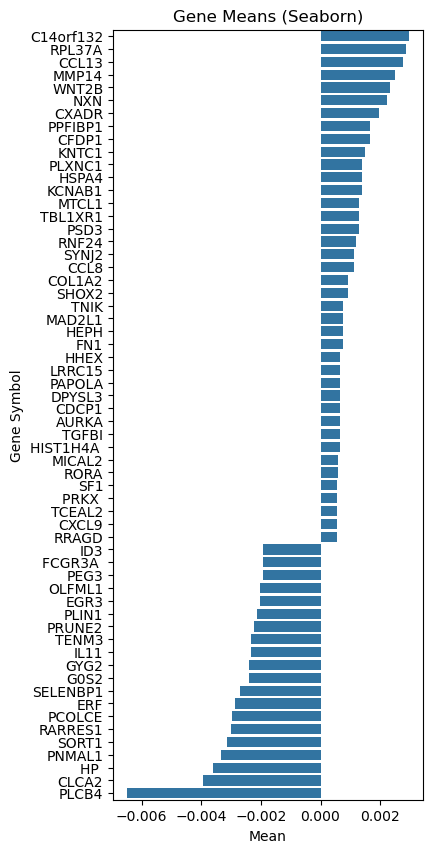

In [91]:
result_df = pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test.columns,
)
merge = pd.merge(result_df, gene_info, how='inner', left_index=True, right_on='ID')
merge = merge.groupby('Gene Symbol')[['importances_mean', 'importances_std']].mean()

df_sorted = merge.sort_values('importances_mean', ascending=False)

top40 = df_sorted.head(40)
bottom20 = df_sorted.tail(20)

#take top 40 and bottom 20
df_subset = pd.concat([top40, bottom20])

#and remove extra test from indes
df_subset.index = df_subset.index.str.split("///", n=1).str[0]

plt.figure(figsize=(4, 10))
sns.barplot(
    data=df_subset,
    x='importances_mean',
    y="Gene Symbol",
)

plt.xlabel("Mean")
plt.ylabel("Gene Symbol")
plt.title("Gene Means (Seaborn)")
#plt.tight_layout()
plt.show()

In [84]:
df_sorted

,importances_mean,importances_std
Gene Symbol,,
C14orf132,0.002966,0.001158
RPL37A,0.002873,0.001131
CCL13,0.002780,0.001758
MMP14,0.002502,0.003822
WNT2B,0.002317,0.001390
...,...,...
SORT1,-0.003151,0.001324
PNMAL1,-0.003336,0.000741
HP /// HPR,-0.003614,0.003086
